# Normal Hopf

This notebook contains the Normal-Hopf reference experiments used in the paper, including persistence diagrams, the $L^1$ norm of the Betti-1 curve, and diagram distances.

## Persistence Diagrams

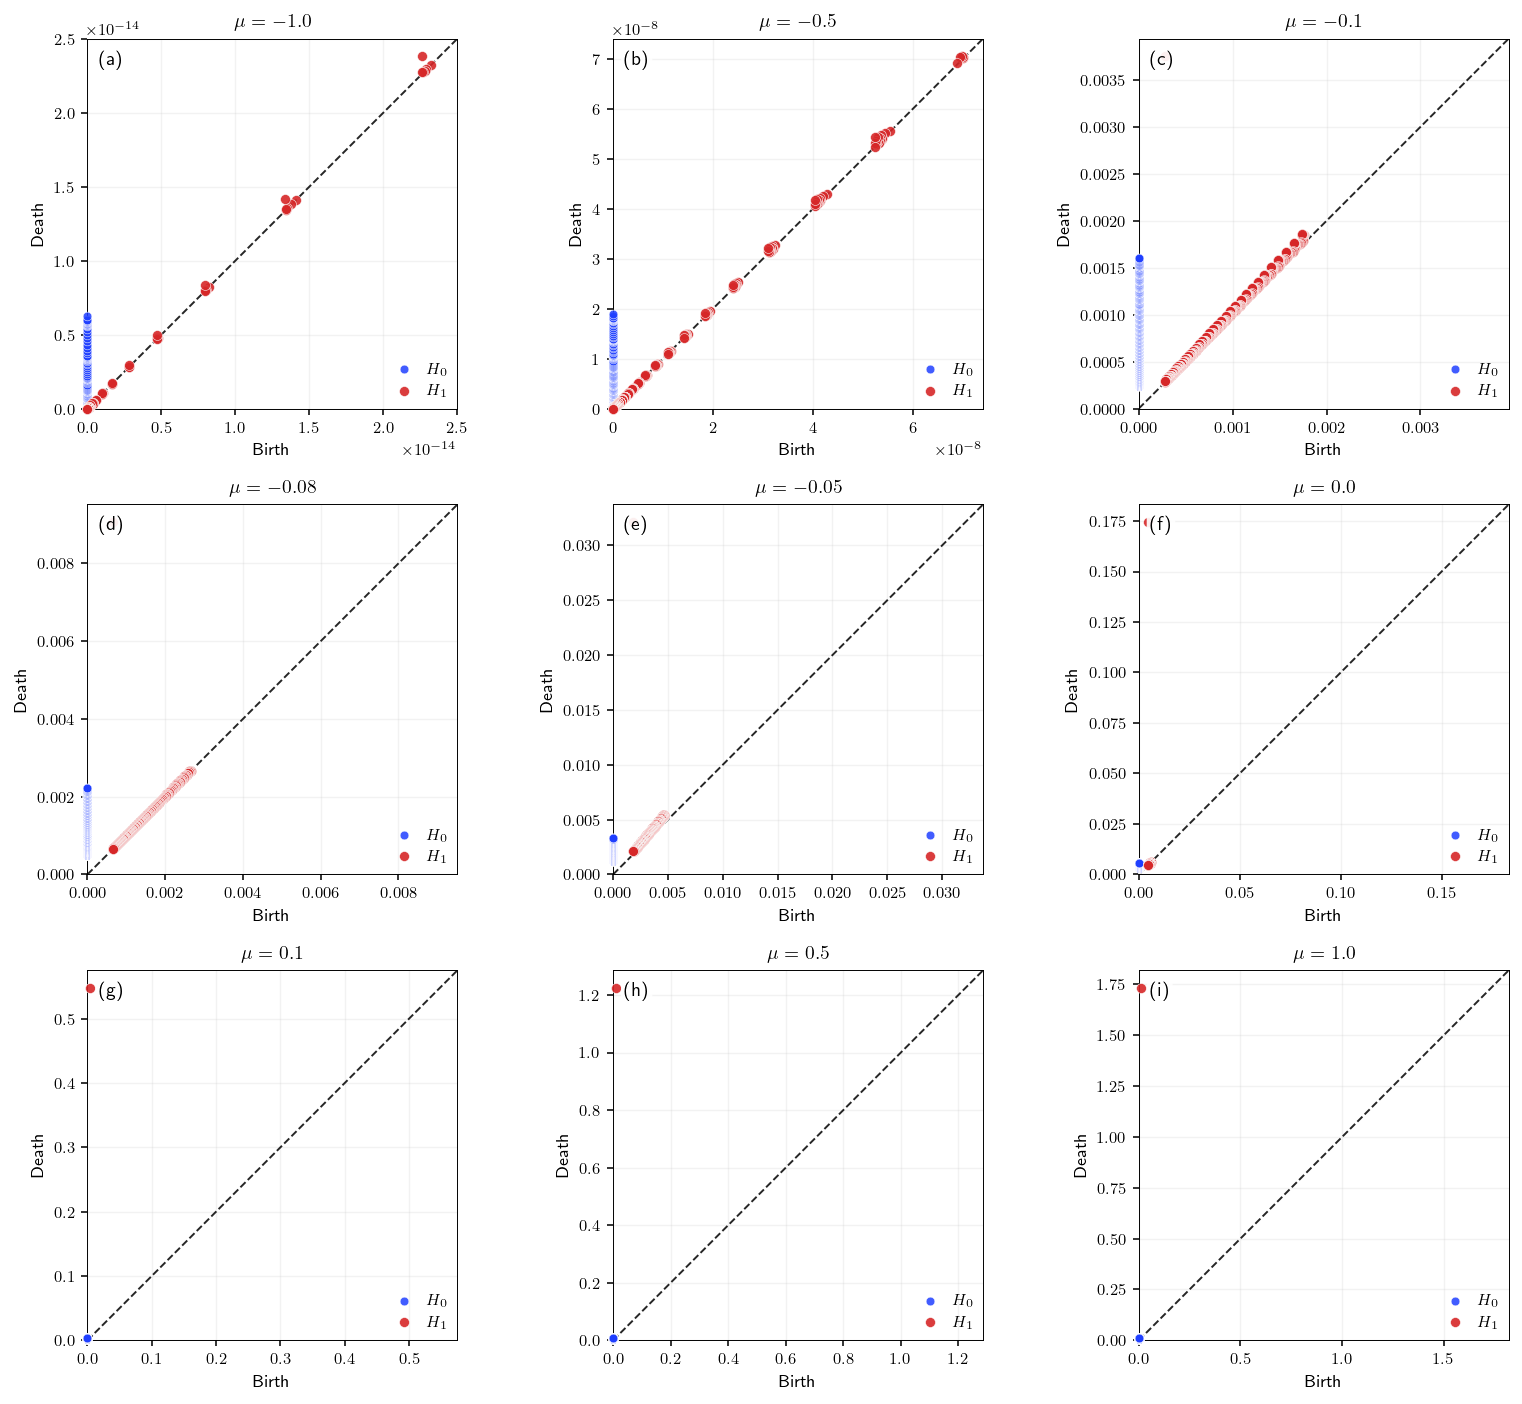

Saved files:
 - figure_hopf_persistence_3x3.png
 - figure_hopf_persistence_3x3.pdf


In [24]:
############################################################
#   3x3 FIGURE OF PERSISTENCE DIAGRAMS FOR HOPF      #
#   using custom RK4, with axes starting at 0 and legends in all panels #
#   + labeling (a)-(i) and points not clipped at the origin  #
############################################################

import numpy as np
import matplotlib.pyplot as plt
from gtda.time_series import SingleTakensEmbedding
from ripser import ripser

# ============================================================
# 1. RK4 integrator
# ============================================================

def rk4_step(f, y, t, dt):
    k1 = np.asarray(f(y, t))
    k2 = np.asarray(f(y + dt/2 * k1, t + dt/2))
    k3 = np.asarray(f(y + dt/2 * k2, t + dt/2))
    k4 = np.asarray(f(y + dt * k3, t + dt))
    return y + dt/6 * (k1 + 2*k2 + 2*k3 + k4)

def rk4_integrate(f, y0, t):
    y = np.zeros((len(t), len(y0)))
    y[0] = y0
    dt = t[1] - t[0]
    for i in range(1, len(t)):
        y[i] = rk4_step(f, y[i-1], t[i-1], dt)
    return y

# ============================================================
# 2. Normal Hopf simulator
# ============================================================

def simulate_hopf(mu, omega=6.0, L=50, fs=100, SampleSize=2000, InitialConditions=None):
    if InitialConditions is None:
        InitialConditions = [0.0, 1.01]

    t = np.linspace(0, L, int(L * fs))

    def hopf_normal(state, t):
        x, y = state
        r2 = x**2 + y**2
        dxdt = mu * x - omega * y - r2 * x
        dydt = omega * x + mu * y - r2 * y
        return dxdt, dydt

    states = rk4_integrate(hopf_normal, InitialConditions, t)

    ts = [
        states[:, 0][-SampleSize:],
        states[:, 1][-SampleSize:]
    ]
    t = t[-SampleSize:]

    return t, ts

# ============================================================
# 3. Global style
# ============================================================

REF_COLOR = "#1F3FFF"   # dark blue #2F5D8A
CHG_COLOR = "#D62728"   # dark red #7A1F1F
DIAG_COLOR = "#000000" # negro suavizado #111111
GRID_COLOR = "#C8C8C8"
BG_COLOR   = "#FFFFFF"

plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.spines.top": True,
    "axes.spines.right": True,
    "axes.facecolor": BG_COLOR,
    "figure.facecolor": "white",
})

def style_2d_axes(ax):
    ax.grid(True, alpha=0.22, color=GRID_COLOR, linewidth=0.7)

    # Complete black borders
    for spine in ["left", "bottom", "top", "right"]:
        ax.spines[spine].set_visible(True)
        ax.spines[spine].set_color("black")
        ax.spines[spine].set_linewidth(0.5)

    ax.tick_params(
        axis="both",
        which="major",
        length=3,
        width=0.8,
        color="black",
        labelcolor="black"
    )
    
    # Axis labels in black
    ax.xaxis.label.set_color("black")
    ax.yaxis.label.set_color("black")

# ============================================================
# 4. Optional noise
# ============================================================

def add_noise(ts, noise_level=0.1, mode="relative", seed=None):
    if seed is not None:
        np.random.seed(seed)

    ts = np.asarray(ts)

    if mode == "relative":
        scale = noise_level * np.std(ts, axis=-1, keepdims=True)
    else:
        scale = noise_level

    noise = scale * np.random.randn(*ts.shape)
    return ts + noise

# ============================================================
# 5. Plotting helper
# ============================================================

panel_labels = list("abcdefghi")

def plot_persistence_panel(ax, dgms, mu, panel_label):
    h0 = dgms[0]
    h1 = dgms[1] if len(dgms) > 1 else np.empty((0, 2))

    h0 = h0[~np.isinf(h0[:, 1])] if len(h0) > 0 else h0
    h1 = h1[~np.isinf(h1[:, 1])] if len(h1) > 0 else h1

    finite_parts = []
    if len(h0) > 0:
        finite_parts.append(h0)
    if len(h1) > 0:
        finite_parts.append(h1)

    # Caso vacío
    if len(finite_parts) == 0:
        ax.set_title(rf"$\mu = {mu}$", pad=6)
        ax.set_xlabel("Birth")
        ax.set_ylabel("Death")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_aspect("equal", adjustable="box")
        style_2d_axes(ax)
        ax.text(
            0.03, 0.97, f"({panel_label})",
            transform=ax.transAxes,
            ha="left", va="top",
            fontsize=10, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.16", facecolor="white", edgecolor="none", alpha=0.92)
        )
        return

    all_pts = np.vstack(finite_parts)

    if len(h0) > 0:
        ax.scatter(
            h0[:, 0], h0[:, 1],
            s=20, color=REF_COLOR, alpha=0.85,
            edgecolors="white", linewidths=0.30,
            label=r"$H_0$",
            zorder=3,
            clip_on=False
        )

    if len(h1) > 0:
        ax.scatter(
            h1[:, 0], h1[:, 1],
            s=26, color=CHG_COLOR, alpha=0.90,
            edgecolors="white", linewidths=0.30,
            label=r"$H_1$",
            zorder=3,
            clip_on=False
        )

    # Forzar que todos los ejes comiencen en 0
    max_val = float(np.max(all_pts))
    if max_val <= 0:
        max_val = 1.0

    pad = 0.05 * max_val
    upper = max_val + pad

    # Diagonal
    ax.plot(
        [0, upper], [0, upper],
        linestyle="--", linewidth=1.0,
        color=DIAG_COLOR, alpha=0.85,
        zorder=2
    )

    ax.set_xlim(0, upper)
    ax.set_ylim(0, upper)
    ax.set_aspect("equal", adjustable="box")

    # pequeño margen visual interno for que no se "coma" los puntos del borde
    ax.margins(x=0.03, y=0.03)

    ax.set_title(rf"$\mu = {mu}$", pad=6)
    ax.set_xlabel("Birth")
    ax.set_ylabel("Death")
    style_2d_axes(ax)

    # Leyenda en todos los paneles
    ax.legend(
        frameon=False,
        loc="lower right",
        fontsize=8,
        handletextpad=0.4,
        borderpad=0.2
    )

    # Numeración (a)-(i)
    ax.text(
        0.03, 0.97, f"({panel_label})",
        transform=ax.transAxes,
        ha="left", va="top",
        fontsize=10, fontweight="bold",
        bbox=dict(
            boxstyle="round,pad=0.16",
            facecolor="white",
            edgecolor="none",
            alpha=0.92
        )
    )

# ============================================================
# 6. Configuración
# ============================================================

mu_values = [-1.0, -0.5, -0.1, -0.08, -0.05, 0.0, 0.1, 0.5, 1.0]

embedding_dimension_2D = 2
embedding_time_delay_2D = 26
stride_2D = 2

embedder_ts_2D = SingleTakensEmbedding(
    parameters_type="fixed",
    time_delay=embedding_time_delay_2D,
    dimension=embedding_dimension_2D,
    stride=stride_2D,
    n_jobs=2
)

ruido = 0.0

# ============================================================
# 7. Figura 3x3
# ============================================================

fig, axs = plt.subplots(3, 3, figsize=(11.5, 10.5))
axs = axs.ravel()

for i, mu in enumerate(mu_values):

    t, ts = simulate_hopf(
        mu=mu,
        omega=6.0,
        L=50,
        fs=100,
        SampleSize=2000,
        InitialConditions=[0.0, 1.01]
    )

    ts = add_noise(ts, noise_level=ruido, mode="relative", seed=42)

    # Serie escalar for Takens
    x_series = np.asarray(ts[0]).ravel()

    X_emb = embedder_ts_2D.fit_transform(x_series)
    dgms = ripser(X_emb, maxdim=1)["dgms"]

    plot_persistence_panel(axs[i], dgms, mu, panel_labels[i])

#fig.suptitle(
    #"Persistence diagrams of Takens embeddings for the Hopf normal form",
    #y=0.98,
    #fontsize=13
#)

fig.tight_layout(rect=[0, 0, 1, 0.965])
fig.savefig("figure_hopf_persistence_3x3.png", bbox_inches="tight")
fig.savefig("figure_hopf_persistence_3x3.pdf", bbox_inches="tight")

plt.show()

print("Saved files:")
print(" - figure_hopf_persistence_3x3.png")
print(" - figure_hopf_persistence_3x3.pdf")

## Betti L1 and Distances

### Block 1 — Complete definitions

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from gtda.time_series import SingleTakensEmbedding
from gtda.homology import VietorisRipsPersistence
from persim import bottleneck, wasserstein
import pandas as pd
import os

# ============================================================
# 1. RK4 integrator
# ============================================================

def rk4_step(f, y, t, dt):
    k1 = np.asarray(f(y, t))
    k2 = np.asarray(f(y + dt/2 * k1, t + dt/2))
    k3 = np.asarray(f(y + dt/2 * k2, t + dt/2))
    k4 = np.asarray(f(y + dt * k3, t + dt))
    return y + dt/6 * (k1 + 2*k2 + 2*k3 + k4)

def rk4_integrate(f, y0, t):
    y = np.zeros((len(t), len(y0)))
    y[0] = y0
    dt = t[1] - t[0]
    for i in range(1, len(t)):
        y[i] = rk4_step(f, y[i-1], t[i-1], dt)
    return y

# ============================================================
# 2. Normal Hopf simulator
# ============================================================

def simulate_hopf(mu, omega=6.0, L=50, fs=100, SampleSize=2000, InitialConditions=None):
    if InitialConditions is None:
        InitialConditions = [0.0, 1.01]

    t = np.linspace(0, L, int(L * fs))

    def hopf_normal(state, t):
        x, y = state
        r2 = x**2 + y**2
        dxdt = mu * x - omega * y - r2 * x
        dydt = omega * x + mu * y - r2 * y
        return dxdt, dydt

    states = rk4_integrate(hopf_normal, InitialConditions, t)

    ts = [
        states[:, 0][-SampleSize:],
        states[:, 1][-SampleSize:]
    ]
    t = t[-SampleSize:]

    return t, ts

# ============================================================
# 3. Plot style
# ============================================================

REF_COLOR = "#1F3FFF"   # dark blue #2F5D8A
CHG_COLOR = "#D62728"   # dark red #7A1F1F
DIAG_COLOR = "#000000" # negro suavizado #111111
GRID_COLOR = "#C8C8C8"
BG_COLOR   = "#FFFFFF"

plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.spines.top": True,
    "axes.spines.right": True,
    "axes.facecolor": BG_COLOR,
    "figure.facecolor": "white",
})

def style_2d_axes(ax):
    ax.grid(True, alpha=0.22, color=GRID_COLOR, linewidth=0.7)

    for spine in ["left", "bottom", "top", "right"]:
        ax.spines[spine].set_visible(True)
        ax.spines[spine].set_color("black")
        ax.spines[spine].set_linewidth(0.5)

    ax.tick_params(
        axis="both",
        which="major",
        length=3,
        width=0.8,
        color="black",
        labelcolor="black"
    )

    ax.xaxis.label.set_color("black")
    ax.yaxis.label.set_color("black")

# ============================================================
# 4. Optional noise
# ============================================================

ruido = 0.00

def add_noise(ts, noise_level=0.1, mode="relative", seed=None):
    if seed is not None:
        np.random.seed(seed)

    ts = np.asarray(ts)

    if mode == "relative":
        scale = noise_level * np.std(ts, axis=-1, keepdims=True)
    else:
        scale = noise_level

    noise = scale * np.random.randn(*ts.shape)
    return ts + noise

# ============================================================
# 5. Takens embedding
# ============================================================

def getTakensEmbedding(x, dim, Tau, dT=2):
    embedder = SingleTakensEmbedding(
        parameters_type="fixed",
        time_delay=Tau,
        dimension=dim,
        stride=dT,
        n_jobs=2
    )
    return embedder.fit_transform(x)

# ============================================================
# 6. Time-series generation
# ============================================================

def generate_hopf_normal_series(mu, sample_size=2000, fs=100):
    _, ts = simulate_hopf(
        mu=mu,
        omega=6.0,
        L=50,
        fs=fs,
        SampleSize=sample_size,
        InitialConditions=[0.0, 1.01]
    )

    ts = add_noise(ts, noise_level=ruido, mode="relative", seed=42)
    return np.asarray(ts[0]).ravel()

# ============================================================
# 7. Topology: H1 diagram + L1 norm of the Betti-1 curve
# ============================================================

def compute_betti_norm_1_and_diagram_gtda(point_cloud, max_edge=20, n_samples=100):
    VR = VietorisRipsPersistence(
        homology_dimensions=[1],
        metric="manhattan",
        max_edge_length=max_edge
    )

    diagrams = VR.fit_transform(point_cloud[None, :, :])
    diag_H1 = diagrams[0]

    # conservar solo birth/death
    diag_H1 = diag_H1[:, :2]

    # eliminar muertes infinitas
    diag_H1 = diag_H1[np.isfinite(diag_H1[:, 1])]

    P = np.linspace(0, max_edge, n_samples)
    betti_1 = np.zeros(n_samples)

    for i, e in enumerate(P):
        betti_1[i] = np.sum((diag_H1[:, 0] <= e) & (e < diag_H1[:, 1]))

    L1_value = np.sum(betti_1)
    return L1_value, diag_H1

# ============================================================
# 8. Parámetros globales
# ============================================================

dim = 2
tau = 26
dT = 2
max_edge = 20
n_betti_samples = 100

# ============================================================
# 9. Topología for un mu
# ============================================================

def compute_topology_for_mu(mu, dim=dim, Tau=tau, dT=dT, max_edge=max_edge, n_samples=n_betti_samples):
    serie_x = generate_hopf_normal_series(mu)
    embedding = getTakensEmbedding(serie_x, dim=dim, Tau=Tau, dT=dT)

    L1_value, diag_H1 = compute_betti_norm_1_and_diagram_gtda(
        embedding,
        max_edge=max_edge,
        n_samples=n_samples
    )

    return L1_value, diag_H1

### Block 2 — Single precomputation

In [38]:
def precompute_hopf_topology(mu_values, dim=dim, Tau=tau, dT=dT, max_edge=max_edge, n_samples=n_betti_samples):
    H1_diagrams = {}
    L1_values = {}

    for i, mu in enumerate(mu_values):
        L1_value, diag_H1 = compute_topology_for_mu(
            mu,
            dim=dim,
            Tau=Tau,
            dT=dT,
            max_edge=max_edge,
            n_samples=n_samples
        )

        H1_diagrams[mu] = diag_H1
        L1_values[mu] = L1_value

        #print(f"mu = {mu:.5f} -> ||Bv_1||_1 = {L1_value:.4f} ({i+1}/{len(mu_values)})")

    return H1_diagrams, L1_values


# ============================================================
# RUNNING THE PRECOMPUTATION
# ============================================================

mu_values = np.round(np.linspace(-1, 1, 300), 3)

H1_diagrams, L1_values = precompute_hopf_topology(
    mu_values,
    dim=dim,
    Tau=tau,
    dT=dT,
    max_edge=max_edge,
    n_samples=n_betti_samples
)

### Block 3 — Plots and export

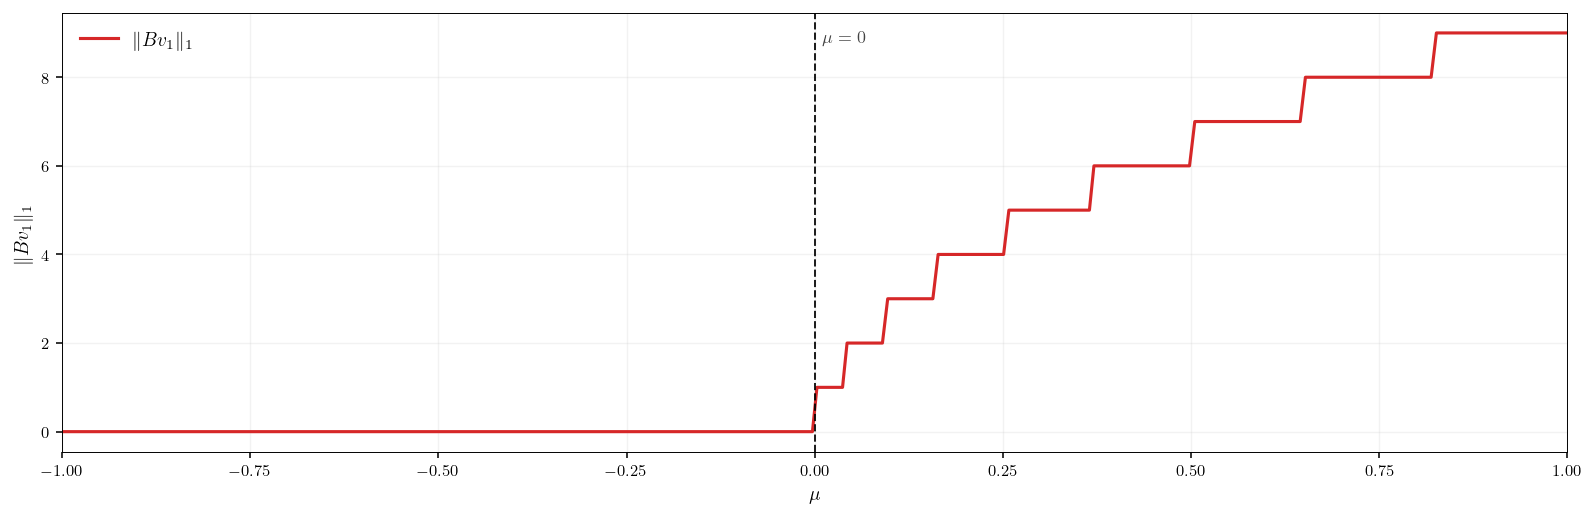


Archivo Excel guardado en:
outputs_hopf_betti1_l1/hopf_betti1_l1_mu_-1_1_n300_Tau26_m2_noise_0.0.xlsx



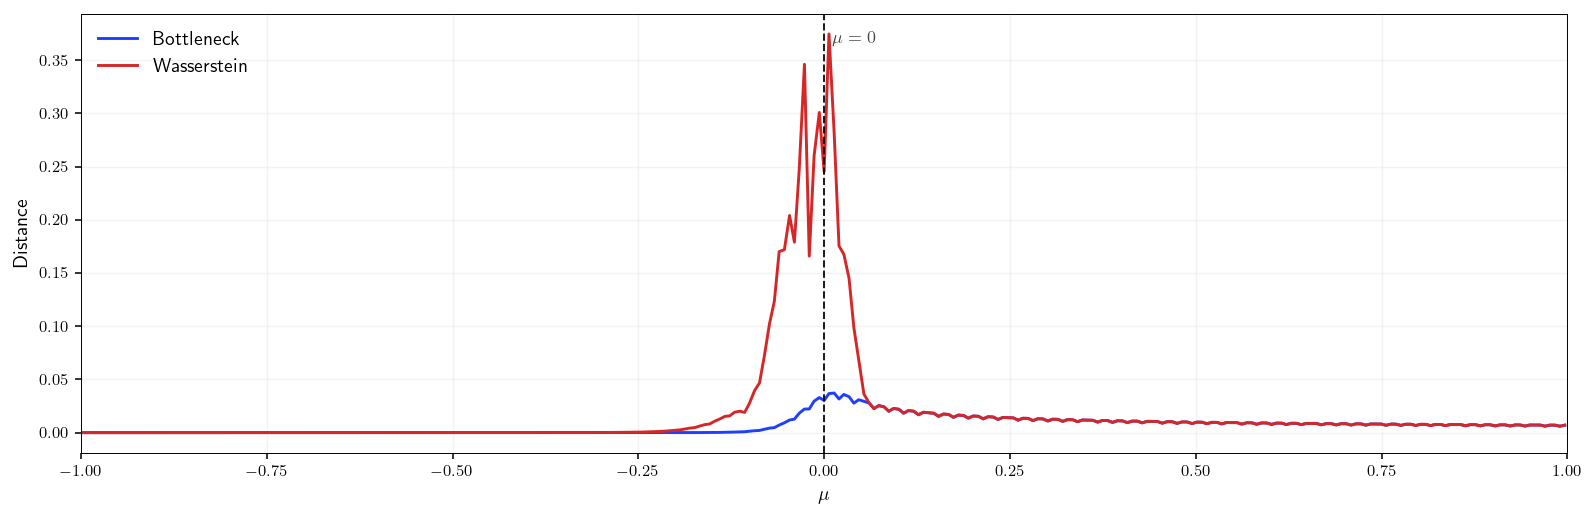


Archivo Excel guardado en:
outputs_hopf_distances/hopf_distances_mu_-1_1_n299_Tau26_m2_noise_0.0.xlsx



In [39]:
# ============================================================
# 1. L1 plot from precomputed results
# ============================================================

def plot_L1_from_precomputed(mu_values, L1_values, save_excel=True):
    mu_vals = list(mu_values)
    L1_norms_1_vals = [L1_values[mu] for mu in mu_vals]

    fig, ax = plt.subplots(figsize=(11.5, 3.8))

    ax.plot(
        mu_vals,
        L1_norms_1_vals,
        color=CHG_COLOR,
        lw=1.6,
        label=r"$\|Bv_1\|_1$"
    )

    ax.axvline(
        0.0,
        color=DIAG_COLOR,
        linestyle="--",
        linewidth=1.0,
        alpha=0.9
    )

    ax.text(
        0.01, 0.96,
        r"$\mu = 0$",
        transform=ax.get_xaxis_transform(),
        ha="left", va="top",
        fontsize=9,
        color="#444444"
    )

    ax.set_xlim(-1, 1)
    ax.set_xticks(np.arange(-1, 1.01, 0.25))
    ax.margins(x=0.01)

    ax.set_xlabel(r"$\mu$")
    ax.set_ylabel(r"$\|Bv_1\|_1$")

    style_2d_axes(ax)
    ax.legend(frameon=False, loc="upper left")

    fig.tight_layout()
    fig.savefig("figure_hopf_betti1_l1.png", bbox_inches="tight")
    fig.savefig("figure_hopf_betti1_l1.pdf", bbox_inches="tight")
    plt.show()

    if save_excel:
        carpeta = "outputs_hopf_betti1_l1"
        os.makedirs(carpeta, exist_ok=True)

        archivo_excel = os.path.join(
            carpeta,
            f"hopf_betti1_l1_mu_-1_1_n{len(mu_values)}_Tau{tau}_m{dim}_noise_{ruido}.xlsx"
        )

        df = pd.DataFrame({
            "mu": mu_vals,
            "L1_norm_Bv1": L1_norms_1_vals
        })
        df.to_excel(archivo_excel, index=False)
        print(f"\nArchivo Excel guardado en:\n{archivo_excel}\n")


# ============================================================
# 2. Distancias desde diagrams precomputados
# ============================================================

def compute_distances_from_precomputed(mu_values, H1_diagrams):
    mu_mid = []
    bottleneck_vals = []
    wasserstein_vals = []

    for i in range(len(mu_values) - 1):
        mu1 = mu_values[i]
        mu2 = mu_values[i + 1]

        dgm1 = H1_diagrams[mu1]
        dgm2 = H1_diagrams[mu2]

        d_b = bottleneck(dgm1, dgm2)
        d_w = wasserstein(dgm1, dgm2)

        mu_mid.append((mu1 + mu2) / 2)
        bottleneck_vals.append(d_b)
        wasserstein_vals.append(d_w)

        #print( f"Distancias entre mu={mu1:.3f} y mu={mu2:.3f} " f"-> Bottleneck={d_b:.4f}, Wasserstein={d_w:.4f}")

    return mu_mid, bottleneck_vals, wasserstein_vals


# ============================================================
# 3. Distance plot
# ============================================================

def plot_distances_from_precomputed(mu_mid, bottleneck_vals, wasserstein_vals, save_excel=True):
    fig, ax = plt.subplots(figsize=(11.5, 3.8))

    ax.plot(
        mu_mid,
        bottleneck_vals,
        color=REF_COLOR,
        lw=1.5,
        label="Bottleneck"
    )

    ax.plot(
        mu_mid,
        wasserstein_vals,
        color=CHG_COLOR,
        lw=1.5,
        label="Wasserstein"
    )

    ax.axvline(
        0.0,
        color=DIAG_COLOR,
        linestyle="--",
        linewidth=1.0,
        alpha=0.9
    )

    ax.text(
        0.01, 0.96,
        r"$\mu = 0$",
        transform=ax.get_xaxis_transform(),
        ha="left", va="top",
        fontsize=9,
        color="#444444"
    )

    ax.set_xlim(-1, 1)
    ax.set_xticks(np.arange(-1, 1.01, 0.25))
    ax.margins(x=0.01)

    ax.set_xlabel(r"$\mu$")
    ax.set_ylabel("Distance")

    style_2d_axes(ax)
    ax.legend(frameon=False, loc="upper left")

    fig.tight_layout()
    fig.savefig("figure_hopf_distances.png", bbox_inches="tight")
    fig.savefig("figure_hopf_distances.pdf", bbox_inches="tight")
    plt.show()

    if save_excel:
        carpeta = "outputs_hopf_distances"
        os.makedirs(carpeta, exist_ok=True)

        archivo_excel = os.path.join(
            carpeta,
            f"hopf_distances_mu_-1_1_n{len(mu_mid)}_Tau{tau}_m{dim}_noise_{ruido}.xlsx"
        )

        df = pd.DataFrame({
            "mu_mid": mu_mid,
            "bottleneck": bottleneck_vals,
            "wasserstein": wasserstein_vals
        })
        df.to_excel(archivo_excel, index=False)
        print(f"\nArchivo Excel guardado en:\n{archivo_excel}\n")


# ============================================================
# 4. RUNNING THE PLOTS
# ============================================================

# L1 plot
plot_L1_from_precomputed(mu_values, L1_values, save_excel=True)

# Distance computation
mu_mid, bottleneck_vals, wasserstein_vals = compute_distances_from_precomputed(
    mu_values,
    H1_diagrams
)

# Distance plot
plot_distances_from_precomputed(
    mu_mid,
    bottleneck_vals,
    wasserstein_vals,
    save_excel=True
)

### Max Persistence

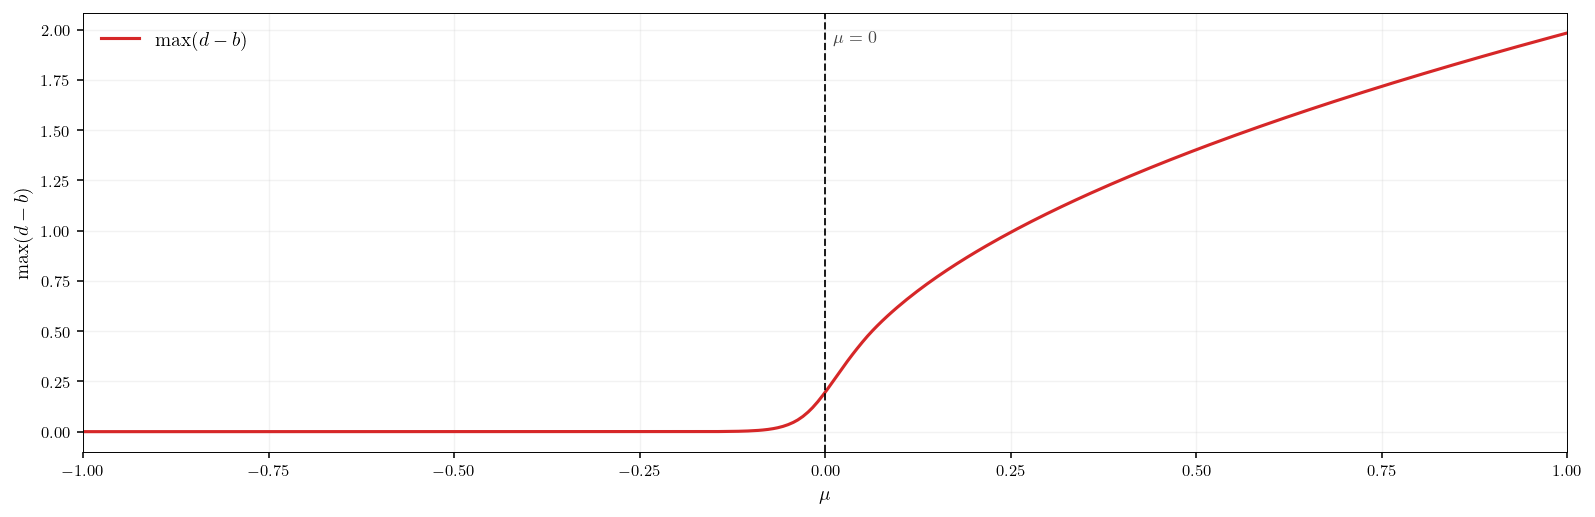


Archivo Excel guardado en:
outputs_hopf_max_persistence/hopf_max_persistence_mu_-1_1_n300_Tau26_m2_noise_0.0.xlsx



In [40]:
import numpy as np
import matplotlib.pyplot as plt
from gtda.time_series import SingleTakensEmbedding
from gtda.homology import VietorisRipsPersistence
import pandas as pd
import os

# ============================================================
# 1. RK4 integrator
# ============================================================

def rk4_step(f, y, t, dt):
    k1 = np.asarray(f(y, t))
    k2 = np.asarray(f(y + dt/2 * k1, t + dt/2))
    k3 = np.asarray(f(y + dt/2 * k2, t + dt/2))
    k4 = np.asarray(f(y + dt * k3, t + dt))
    return y + dt/6 * (k1 + 2*k2 + 2*k3 + k4)

def rk4_integrate(f, y0, t):
    y = np.zeros((len(t), len(y0)))
    y[0] = y0
    dt = t[1] - t[0]
    for i in range(1, len(t)):
        y[i] = rk4_step(f, y[i-1], t[i-1], dt)
    return y

# ============================================================
# 2. Normal Hopf simulator
# ============================================================

def simulate_hopf(mu, omega=6.0, L=50, fs=100, SampleSize=2000, InitialConditions=None):
    if InitialConditions is None:
        InitialConditions = [0.0, 1.01]

    t = np.linspace(0, L, int(L * fs))

    def hopf_normal(state, t):
        x, y = state
        r2 = x**2 + y**2
        dxdt = mu * x - omega * y - r2 * x
        dydt = omega * x + mu * y - r2 * y
        return dxdt, dydt

    states = rk4_integrate(hopf_normal, InitialConditions, t)

    ts = [
        states[:, 0][-SampleSize:],
        states[:, 1][-SampleSize:]
    ]
    t = t[-SampleSize:]

    return t, ts

# ============================================================
# 3. Plot style
# ============================================================

REF_COLOR = "#1F3FFF"   # dark blue #2F5D8A
CHG_COLOR = "#D62728"   # dark red #7A1F1F
DIAG_COLOR = "#000000" # negro suavizado #111111
GRID_COLOR = "#C8C8C8"
BG_COLOR   = "#FFFFFF"

plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.spines.top": True,
    "axes.spines.right": True,
    "axes.facecolor": BG_COLOR,
    "figure.facecolor": "white",
})

def style_2d_axes(ax):
    ax.grid(True, alpha=0.22, color=GRID_COLOR, linewidth=0.7)

    for spine in ["left", "bottom", "top", "right"]:
        ax.spines[spine].set_visible(True)
        ax.spines[spine].set_color("black")
        ax.spines[spine].set_linewidth(0.5)

    ax.tick_params(
        axis="both",
        which="major",
        length=3,
        width=0.8,
        color="black",
        labelcolor="black"
    )

    ax.xaxis.label.set_color("black")
    ax.yaxis.label.set_color("black")

# ============================================================
# 4. Optional noise
# ============================================================

ruido = 0.00

def add_noise(ts, noise_level=0.1, mode="relative", seed=None):
    if seed is not None:
        np.random.seed(seed)

    ts = np.asarray(ts)

    if mode == "relative":
        scale = noise_level * np.std(ts, axis=-1, keepdims=True)
    else:
        scale = noise_level

    noise = scale * np.random.randn(*ts.shape)
    return ts + noise

# ============================================================
# 5. Takens embedding
# ============================================================

def getTakensEmbedding(x, dim, Tau, dT=2):
    embedder = SingleTakensEmbedding(
        parameters_type="fixed",
        time_delay=Tau,
        dimension=dim,
        stride=dT,
        n_jobs=2
    )
    return embedder.fit_transform(x)

# ============================================================
# 6. Time-series generation
# ============================================================

def generate_hopf_normal_series(mu, sample_size=2000, fs=100):
    _, ts = simulate_hopf(
        mu=mu,
        omega=6.0,
        L=50,
        fs=fs,
        SampleSize=sample_size,
        InitialConditions=[0.0, 1.01]
    )

    ts = add_noise(ts, noise_level=ruido, mode="relative", seed=42)
    return np.asarray(ts[0]).ravel()

# ============================================================
# 7. Computation of the H1 diagram and max persistence
# ============================================================

def compute_max_persistence_and_diagram(point_cloud, max_edge=20):
    VR = VietorisRipsPersistence(
        homology_dimensions=[1],
        metric="manhattan",
        max_edge_length=max_edge
    )

    diagrams = VR.fit_transform(point_cloud[None, :, :])
    diag_H1 = diagrams[0][:, :2]

    # quitar muertes infinitas
    diag_H1 = diag_H1[np.isfinite(diag_H1[:, 1])]

    if diag_H1.shape[0] == 0:
        max_persistence = 0.0
    else:
        persistences = diag_H1[:, 1] - diag_H1[:, 0]
        max_persistence = np.max(persistences)

    return max_persistence, diag_H1

# ============================================================
# 8. Parámetros globales
# ============================================================

dim = 2
tau = 26
dT = 2
max_edge = 20

# ============================================================
# 9. Topología por cada mu
# ============================================================

def compute_max_persistence_for_mu(mu, dim=dim, Tau=tau, dT=dT, max_edge=max_edge):
    serie_x = generate_hopf_normal_series(mu)
    embedding = getTakensEmbedding(serie_x, dim=dim, Tau=Tau, dT=dT)

    max_persistence, diag_H1 = compute_max_persistence_and_diagram(
        embedding,
        max_edge=max_edge
    )

    return max_persistence, diag_H1

# ============================================================
# 10. Precomputación
# ============================================================

def precompute_max_persistence(mu_values, dim=dim, Tau=tau, dT=dT, max_edge=max_edge):
    H1_diagrams = {}
    max_persistence_values = {}

    for i, mu in enumerate(mu_values):
        mp, diag_H1 = compute_max_persistence_for_mu(
            mu,
            dim=dim,
            Tau=Tau,
            dT=dT,
            max_edge=max_edge
        )

        H1_diagrams[mu] = diag_H1
        max_persistence_values[mu] = mp

        #print(f"mu = {mu:.5f} -> max persistence = {mp:.6f} ({i+1}/{len(mu_values)})")

    return H1_diagrams, max_persistence_values

# ============================================================
# 11. Gráfica principal
# ============================================================

def plot_max_persistence(mu_values, max_persistence_values, save_excel=True):
    mu_vals = list(mu_values)
    mp_vals = [max_persistence_values[mu] for mu in mu_vals]

    fig, ax = plt.subplots(figsize=(11.5, 3.8))

    ax.plot(
        mu_vals,
        mp_vals,
        color=CHG_COLOR,
        lw=1.6,
        label=r"$\max(d-b)$"
    )

    ax.axvline(
        0.0,
        color=DIAG_COLOR,
        linestyle="--",
        linewidth=1.0,
        alpha=0.9
    )

    ax.text(
        0.01, 0.96,
        r"$\mu = 0$",
        transform=ax.get_xaxis_transform(),
        ha="left", va="top",
        fontsize=9,
        color="#444444"
    )

    ax.set_xlim(-1, 1)
    ax.set_xticks(np.arange(-1, 1.01, 0.25))
    ax.margins(x=0.01)

    ax.set_xlabel(r"$\mu$")
    ax.set_ylabel(r"$\max(d-b)$")

    style_2d_axes(ax)
    ax.legend(frameon=False, loc="upper left")

    fig.tight_layout()
    fig.savefig("figure_hopf_max_persistence.png", bbox_inches="tight")
    fig.savefig("figure_hopf_max_persistence.pdf", bbox_inches="tight")
    plt.show()

    if save_excel:
        carpeta = "outputs_hopf_max_persistence"
        os.makedirs(carpeta, exist_ok=True)

        archivo_excel = os.path.join(
            carpeta,
            f"hopf_max_persistence_mu_-1_1_n{len(mu_values)}_Tau{tau}_m{dim}_noise_{ruido}.xlsx"
        )

        df = pd.DataFrame({
            "mu": mu_vals,
            "max_persistence_H1": mp_vals
        })
        df.to_excel(archivo_excel, index=False)
        print(f"\nArchivo Excel guardado en:\n{archivo_excel}\n")

# ============================================================
# 12. Ejecución
# ============================================================

mu_values = np.round(np.linspace(-1, 1, 300), 3)

H1_diagrams, max_persistence_values = precompute_max_persistence(
    mu_values,
    dim=dim,
    Tau=tau,
    dT=dT,
    max_edge=max_edge
)

plot_max_persistence(
    mu_values,
    max_persistence_values,
    save_excel=True
)